In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [ ]:
sns.set_theme(style='darkgrid')
df = pd.read_csv("/content/sample_data/student_placement_synthetic.csv")

In [ ]:
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,68475.000000
mean,7.206381,0.547010,5.995147,5.500711,64.990511,5.990614,4.508752,4.008210,1.095040,2.397280,1.49985,0.745840,0.450990,1.151100,0.684750,17.308014
std,0.925235,0.862727,1.496302,1.781961,11.990892,1.496552,1.968278,1.778405,0.940264,1.242829,1.11407,0.884189,0.671061,0.965162,0.464618,2.601041
min,4.000000,0.000000,1.000000,1.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,6.880000
25%,6.580000,0.000000,5.000000,4.300000,56.800000,5.000000,3.200000,2.800000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,15.530000
50%,7.210000,0.000000,6.000000,5.500000,65.000000,6.000000,4.500000,4.000000,1.000000,2.000000,1.00000,0.000000,0.000000,1.000000,1.000000,17.250000
75%,7.830000,1.000000,7.000000,6.700000,73.100000,7.000000,5.900000,5.200000,2.000000,3.000000,2.00000,1.000000,1.000000,2.000000,1.000000,19.040000
max,10.000000,3.000000,10.000000,10.000000,100.000000,10.000000,10.000000,10.000000,3.000000,5.000000,4.00000,3.000000,2.000000,3.000000,1.000000,28.330000


In [ ]:
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nPlacement Rate:", round(df['placement_status'].mean() * 100, 2), "%")
print("Avg Salary (Placed):", round(df['salary_package_lpa'].mean(), 2), "LPA")
df.describe()

Shape: (100000, 18)

Missing Values:
 branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64

Placement Rate: 68.47 %
Avg Salary (Placed): 17.31 LPA


,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,68475.000000
mean,7.206381,0.547010,5.995147,5.500711,64.990511,5.990614,4.508752,4.008210,1.095040,2.397280,1.49985,0.745840,0.450990,1.151100,0.684750,17.308014
std,0.925235,0.862727,1.496302,1.781961,11.990892,1.496552,1.968278,1.778405,0.940264,1.242829,1.11407,0.884189,0.671061,0.965162,0.464618,2.601041
min,4.000000,0.000000,1.000000,1.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,6.880000
25%,6.580000,0.000000,5.000000,4.300000,56.800000,5.000000,3.200000,2.800000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,15.530000
50%,7.210000,0.000000,6.000000,5.500000,65.000000,6.000000,4.500000,4.000000,1.000000,2.000000,1.00000,0.000000,0.000000,1.000000,1.000000,17.250000
75%,7.830000,1.000000,7.000000,6.700000,73.100000,7.000000,5.900000,5.200000,2.000000,3.000000,2.00000,1.000000,1.000000,2.000000,1.000000,19.040000
max,10.000000,3.000000,10.000000,10.000000,100.000000,10.000000,10.000000,10.000000,3.000000,5.000000,4.00000,3.000000,2.000000,3.000000,1.000000,28.330000


**EDA**

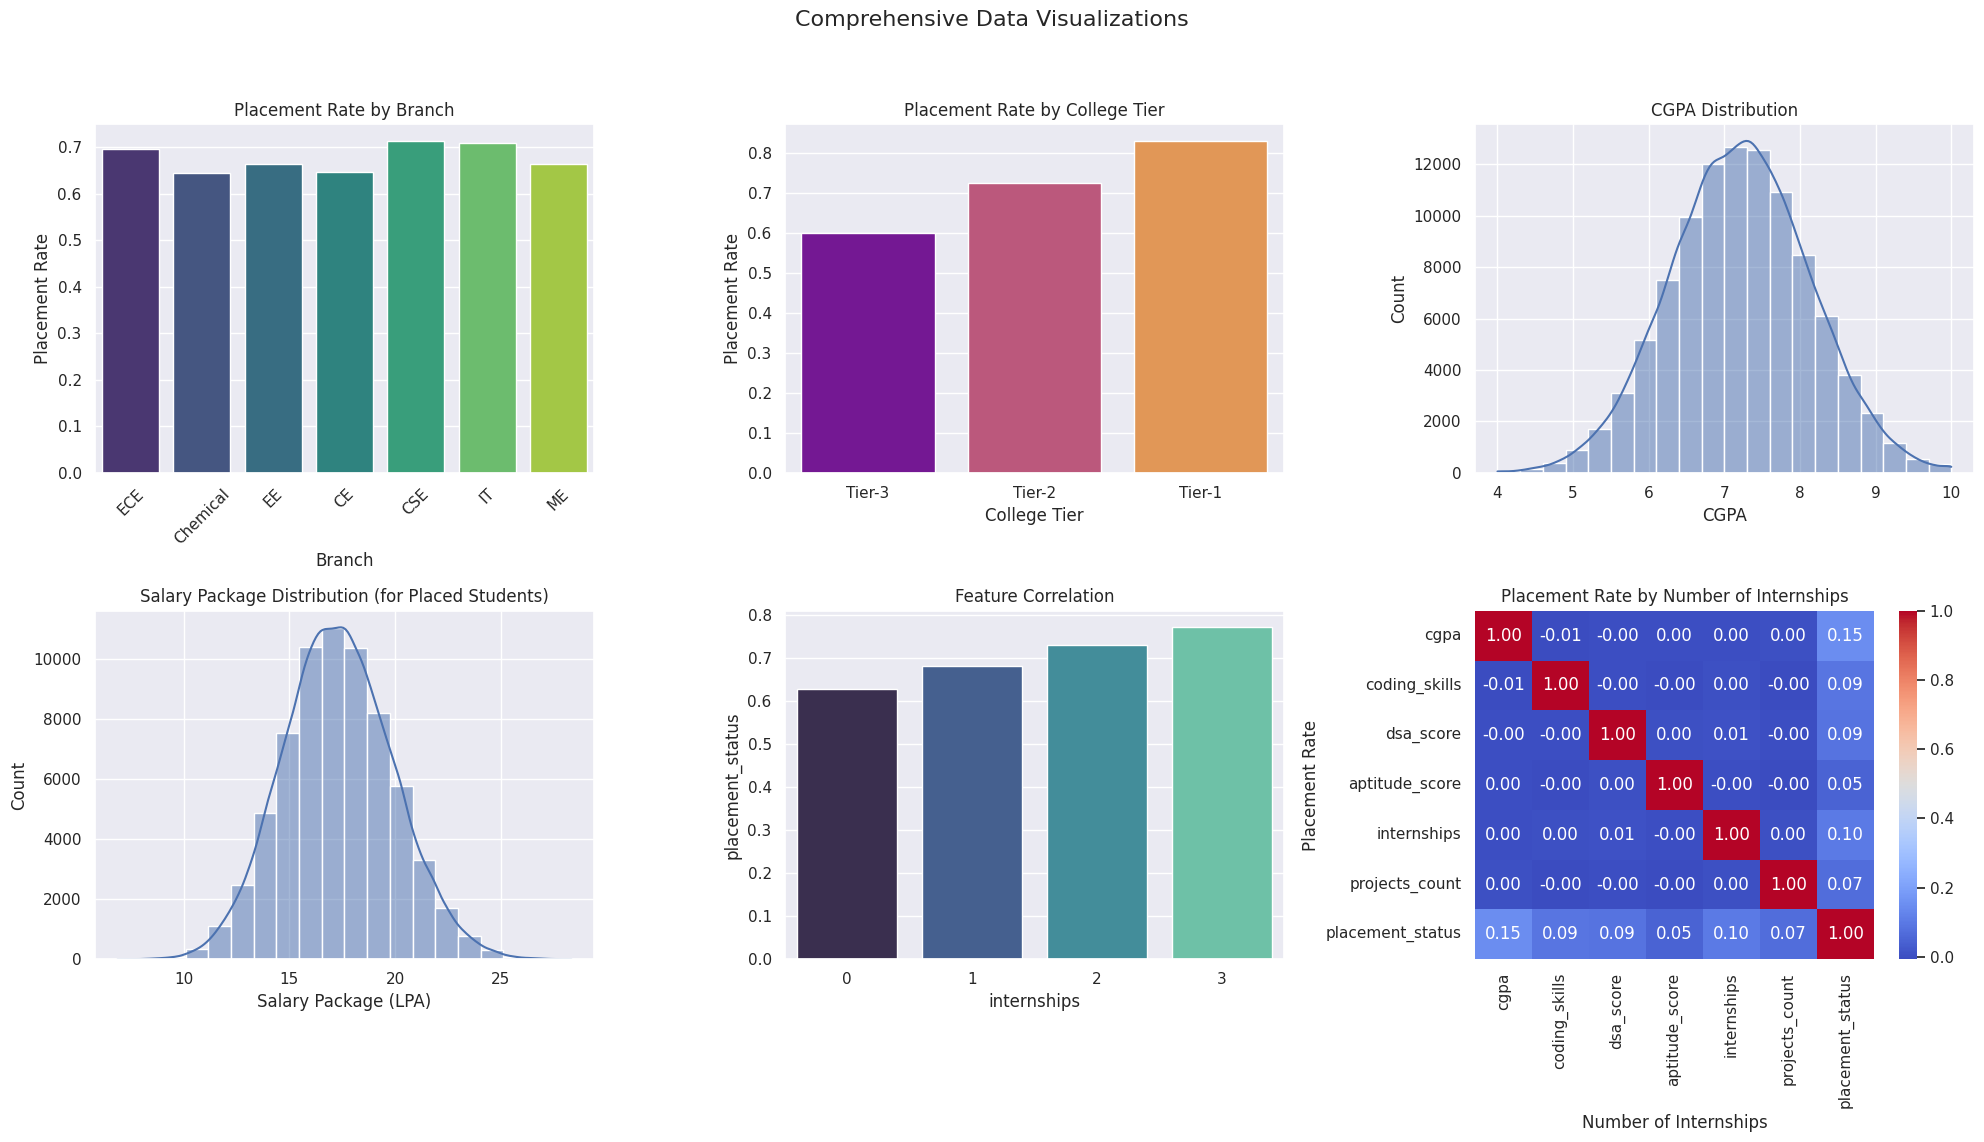

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Comprehensive Data Visualizations', fontsize=16)

# Placement Rate by Branch
sns.barplot(x='branch', y='placement_status', data=df, errorbar=None, palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Placement Rate by Branch')
axes[0, 0].set_xlabel('Branch')
axes[0, 0].set_ylabel('Placement Rate')
axes[0, 0].tick_params(axis='x', rotation=45)

# Placement Rate by College Tier
sns.barplot(x='college_tier', y='placement_status', data=df, errorbar=None, palette='plasma', ax=axes[0, 1])
axes[0, 1].set_title('Placement Rate by College Tier')
axes[0, 1].set_xlabel('College Tier')
axes[0, 1].set_ylabel('Placement Rate')

# CGPA Distribution
sns.histplot(data=df, x='cgpa', kde=True, bins=20, palette='viridis', ax=axes[0, 2])
axes[0, 2].set_title('CGPA Distribution')
axes[0, 2].set_xlabel('CGPA')
axes[0, 2].set_ylabel('Count')

# Salary Package Distribution (for Placed Students)
sns.histplot(data=df.dropna(subset=['salary_package_lpa']), x='salary_package_lpa', kde=True, bins=20, palette='magma', ax=axes[1, 0])
axes[1, 0].set_title('Salary Package Distribution (for Placed Students)')
axes[1, 0].set_xlabel('Salary Package (LPA)')
axes[1, 0].set_ylabel('Count')

# Correlation heatmap
num_cols = ['cgpa','coding_skills','dsa_score','aptitude_score','internships','projects_count','placement_status']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', ax=axes[1,2], cmap='coolwarm')
axes[1,1].set_title('Feature Correlation')

# Placement Rate by Number of Internships
sns.barplot(x='internships', y='placement_status', data=df, errorbar=None, palette='mako', ax=axes[1, 1])
axes[1, 2].set_title('Placement Rate by Number of Internships')
axes[1, 2].set_xlabel('Number of Internships')
axes[1, 2].set_ylabel('Placement Rate')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

**Classification for Placement_Status**

In [ ]:


features = ['cgpa','coding_skills','dsa_score','aptitude_score',
            'communication_skills','ml_knowledge','system_design',
            'internships','projects_count','certifications',
            'hackathons','backlogs']

X = df[features]
y = df['placement_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(classification_report(y_test, lr_pred))

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred))

=== Logistic Regression ===
Accuracy: 0.6907
              precision    recall  f1-score   support

           0       0.55      0.13      0.21      6335
           1       0.70      0.95      0.81     13665

    accuracy                           0.69     20000
   macro avg       0.63      0.54      0.51     20000
weighted avg       0.65      0.69      0.62     20000

=== Random Forest ===
Accuracy: 0.6844
              precision    recall  f1-score   support

           0       0.51      0.15      0.23      6335
           1       0.70      0.93      0.80     13665

    accuracy                           0.68     20000
   macro avg       0.60      0.54      0.51     20000
weighted avg       0.64      0.68      0.62     20000



**regression model to predict salary_package_lpa**

### XGBoost and LightGBM for Salary Prediction

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Filter for placed students as salary is only available for them
df_placed = df[df['placement_status'] == 1].dropna(subset=['salary_package_lpa']).copy()

# Define features for regression model
reg_features = ['cgpa', 'coding_skills', 'dsa_score', 'aptitude_score',
                'communication_skills', 'ml_knowledge', 'system_design',
                'internships', 'projects_count', 'certifications',
                'hackathons', 'backlogs', 'open_source_contributions',
                'extracurriculars', 'branch', 'college_tier']

X_reg = df_placed[reg_features]
y_reg = df_placed['salary_package_lpa']

# One-hot encode categorical features
X_reg = pd.get_dummies(X_reg, columns=['branch', 'college_tier'], drop_first=True)

# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
lin_reg_pred = lin_reg.predict(X_test_reg)

# Random Forest Regressor Model
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)
rf_reg_pred = rf_reg.predict(X_test_reg)

print("=== Linear Regression for Salary Prediction ===")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_reg, lin_reg_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test_reg, lin_reg_pred):.4f}")
print(f"R-squared: {r2_score(y_test_reg, lin_reg_pred):.4f}")

print("\n=== Random Forest Regression for Salary Prediction ===")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_reg, rf_reg_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test_reg, rf_reg_pred):.4f}")
print(f"R-squared: {r2_score(y_test_reg, rf_reg_pred):.4f}")

=== Linear Regression for Salary Prediction ===
Mean Absolute Error: 0.9454
Mean Squared Error: 1.4049
R-squared: 0.7914

=== Random Forest Regression for Salary Prediction ===
Mean Absolute Error: 1.0207
Mean Squared Error: 1.6396
R-squared: 0.7566


### XGBoost and LightGBM for Salary Prediction

In [ ]:
pip install xgboost lightgbm

In [ ]:
from xgboost import XGBRegressor

# XGBoost Regressor Model
xgb_reg = XGBRegressor(n_estimators=100, random_state=42)
xgb_reg.fit(X_train_reg, y_train_reg)
xgb_reg_pred = xgb_reg.predict(X_test_reg)

print("\n=== XGBoost Regression for Salary Prediction ===")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_reg, xgb_reg_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test_reg, xgb_reg_pred):.4f}")
print(f"R-squared: {r2_score(y_test_reg, xgb_reg_pred):.4f}")


=== XGBoost Regression for Salary Prediction ===
Mean Absolute Error: 0.9999
Mean Squared Error: 1.5669
R-squared: 0.7674


In [ ]:
from lightgbm import LGBMRegressor

# LightGBM Regressor Model
lgbm_reg = LGBMRegressor(n_estimators=100, random_state=42)
lgbm_reg.fit(X_train_reg, y_train_reg)
lgbm_reg_pred = lgbm_reg.predict(X_test_reg)

print("\n=== LightGBM Regression for Salary Prediction ===")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_reg, lgbm_reg_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test_reg, lgbm_reg_pred):.4f}")
print(f"R-squared: {r2_score(y_test_reg, lgbm_reg_pred):.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1032
[LightGBM] [Info] Number of data points in the train set: 54780, number of used features: 22
[LightGBM] [Info] Start training from score 17.301476

=== LightGBM Regression for Salary Prediction ===
Mean Absolute Error: 0.9653
Mean Squared Error: 1.4657
R-squared: 0.7824


In [ ]:
import joblib

# Define the filename for the model
model_filename = 'linear_regression_model.joblib'

# Save the trained Linear Regression model
joblib.dump(lin_reg, model_filename)

print(f"Linear Regression model saved to '{model_filename}'")

Linear Regression model saved to 'linear_regression_model.joblib'


### Save the Placement Prediction Model (Logistic Regression)

In [ ]:
import joblib

# Define filename for the placement model
placement_model_filename = 'logistic_regression_placement_model.joblib'

# Save the trained Logistic Regression model
joblib.dump(lr, placement_model_filename)

print(f"Logistic Regression model for placement saved to '{placement_model_filename}'")

Logistic Regression model for placement saved to 'logistic_regression_placement_model.joblib'
